# Interior-Point Method: Portfolio QP with a No-Short-Selling Constraint

## Problem

The same mean-variance problem as in `quadratic_programming.ipynb`, but with a long-only
constraint added:

```
minimize    (1/2) w^T Sigma w
subject to  w^T mu = r_target
            w^T 1  = 1
            w_i >= 0   for all i
```

Unlike the equality-only case, the set of active inequality constraints (which weights end up
at exactly zero) is not known in advance, so the problem can no longer be solved by a single
linear solve — an iterative method is required.

## Method

A **primal-dual interior-point method with a logarithmic barrier** (infeasible-start variant).
Introduce a dual variable `z >= 0` for the bound constraints; the perturbed KKT (barrier)
conditions are

```
Sigma w - A^T lambda - z = 0        (stationarity)
A w - b = 0                          (primal equality feasibility)
W Z 1 = mu_barrier * 1               (perturbed complementarity, W = diag(w), Z = diag(z))
```

At each iteration, Newton's method is applied to this (generally infeasible) system to get a
step `(dw, dlambda, dz)`:

```
[ Sigma   -A^T   -I ] [dw     ]   [-(Sigma w - A^T lambda - z)]
[ A        0      0 ] [dlambda] = [-(A w - b)                 ]
[ Z        0      W ] [dz     ]   [-(W Z 1 - mu_barrier * 1)  ]
```

A fraction-to-the-boundary rule keeps `w` and `z` strictly positive, and the barrier parameter
`mu_barrier` is reduced each iteration in proportion to the duality gap `w^T z / n` (a centering
strategy). Convergence is measured by the duality gap and the primal/dual residual norms — all
driven to numerical zero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([0.08, 0.12, 0.10, 0.14, 0.09])
vol = np.array([0.15, 0.22, 0.18, 0.28, 0.16])
corr = np.array([
    [1.00, 0.30, 0.20, 0.10, 0.25],
    [0.30, 1.00, 0.25, 0.15, 0.20],
    [0.20, 0.25, 1.00, 0.20, 0.10],
    [0.10, 0.15, 0.20, 1.00, 0.05],
    [0.25, 0.20, 0.10, 0.05, 1.00],
])
Sigma = np.outer(vol, vol) * corr
n = len(mu)

# Target return chosen so the equality-only QP would short an asset (w_1 < 0),
# forcing the w >= 0 constraint to bind here.
r_target = 0.1143

A = np.vstack([mu, np.ones(n)])
b = np.array([r_target, 1.0])
m = A.shape[0]

def interior_point_qp(sigma_centering=0.3, tol=1e-10, max_it=100):
    w = np.ones(n) / n
    lam = np.zeros(m)
    z = np.ones(n)
    history = []

    for it in range(max_it):
        r_dual = Sigma @ w - A.T @ lam - z
        r_primal = A @ w - b
        duality_gap = (w @ z) / n
        history.append((it, duality_gap, np.linalg.norm(r_dual), np.linalg.norm(r_primal)))
        if duality_gap < tol and np.linalg.norm(r_dual) < tol and np.linalg.norm(r_primal) < tol:
            break

        target_mu = sigma_centering * duality_gap
        W, Z = np.diag(w), np.diag(z)

        KKT = np.zeros((n + m + n, n + m + n))
        KKT[:n, :n] = Sigma
        KKT[:n, n:n + m] = -A.T
        KKT[:n, n + m:] = -np.eye(n)
        KKT[n:n + m, :n] = A
        KKT[n + m:, :n] = Z
        KKT[n + m:, n + m:] = W

        rhs = np.zeros(n + m + n)
        rhs[:n] = -r_dual
        rhs[n:n + m] = -r_primal
        rhs[n + m:] = -(w * z - target_mu)

        step = np.linalg.solve(KKT, rhs)
        dw, dlam, dz = step[:n], step[n:n + m], step[n + m:]

        alpha = 1.0
        neg_w = dw < 0
        if np.any(neg_w):
            alpha = min(alpha, 0.995 * np.min(-w[neg_w] / dw[neg_w]))
        neg_z = dz < 0
        if np.any(neg_z):
            alpha = min(alpha, 0.995 * np.min(-z[neg_z] / dz[neg_z]))

        w = w + alpha * dw
        lam = lam + alpha * dlam
        z = z + alpha * dz

    return w, lam, z, history

w_star, lam_star, z_star, history = interior_point_qp()

print(f"{'iter':>5} {'duality gap':>14} {'||r_dual||':>14} {'||r_primal||':>14}")
for it, gap, rd, rp in history:
    print(f"{it:5d} {gap:14.3e} {rd:14.3e} {rp:14.3e}")

print()
print("w* =", np.round(w_star, 6))
print(f"sum(w*) = {w_star.sum():.10f}   w*.mu = {w_star @ mu:.10f}   variance = {w_star @ Sigma @ w_star:.6f}")


 iter    duality gap     ||r_dual||   ||r_primal||
    0      2.000e-01      2.206e+00      8.300e-03
    1      7.615e-02      5.258e-01      1.979e-03
    2      2.731e-02      3.557e-16      1.388e-17
    3      8.193e-03      8.967e-17      0.000e+00
    4      2.461e-03      3.941e-17      1.388e-17
    5      7.486e-04      2.047e-17      1.119e-16
    6      2.332e-04      1.660e-17      1.388e-17
    7      7.691e-05      1.136e-17      2.225e-16
    8      2.642e-05      1.329e-17      1.119e-16
    9      9.151e-06      5.822e-18      1.388e-17
   10      3.133e-06      4.628e-18      1.110e-16
   11      1.035e-06      8.317e-18      0.000e+00
   12      3.251e-07      8.613e-18      1.388e-17
   13      9.879e-08      1.064e-17      1.388e-17
   14      2.973e-08      4.334e-18      1.388e-17
   15      8.926e-09      3.059e-18      0.000e+00
   16      2.679e-09      5.169e-18      0.000e+00
   17      8.036e-10      5.731e-18      2.220e-16
   18      2.411e-10      8.141

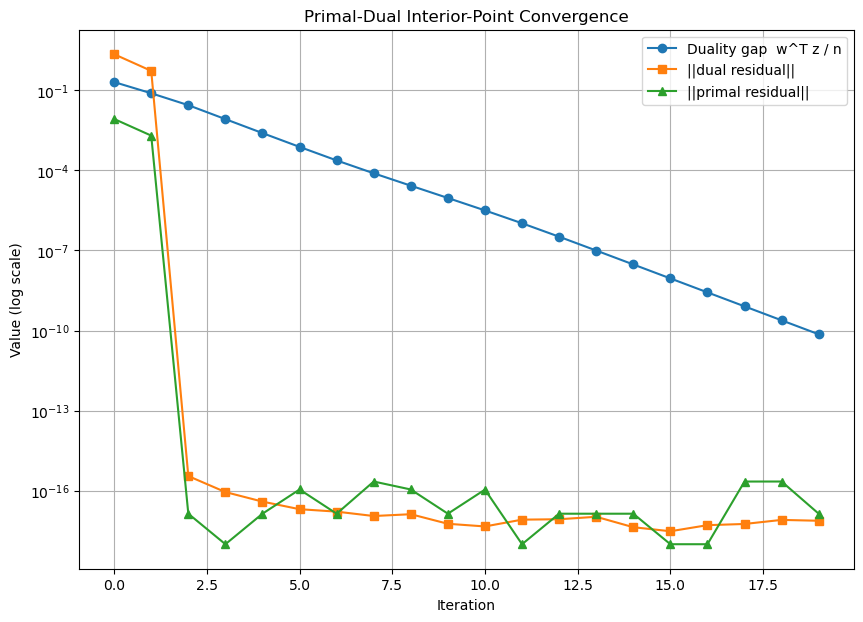

In [2]:
# Convergence plot: duality gap and residual norms vs. iteration
its = [row[0] for row in history]
gaps = [row[1] for row in history]
rduals = [row[2] for row in history]
rprimals = [row[3] for row in history]

plt.figure(figsize=(10, 7))
plt.semilogy(its, gaps, marker='o', label='Duality gap  w^T z / n')
plt.semilogy(its, [max(r, 1e-18) for r in rduals], marker='s', label='||dual residual||')
plt.semilogy(its, [max(r, 1e-18) for r in rprimals], marker='^', label='||primal residual||')
plt.xlabel('Iteration')
plt.ylabel('Value (log scale)')
plt.title('Primal-Dual Interior-Point Convergence')
plt.grid(True, which='both')
plt.legend()
plt.savefig('interior_point_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# Cross-check against the equality-only QP (no short-sale constraint) at the same r_target
def min_variance_no_bound(r_target):
    A2 = np.vstack([mu, np.ones(n)])
    b2 = np.array([r_target, 1.0])
    KKT = np.zeros((n + 2, n + 2))
    KKT[:n, :n] = Sigma
    KKT[:n, n:] = -A2.T
    KKT[n:, :n] = A2
    rhs = np.zeros(n + 2)
    rhs[n:] = b2
    sol = np.linalg.solve(KKT, rhs)
    return sol[:n]

w_unconstrained = min_variance_no_bound(r_target)
print("Equality-only QP weights:      ", np.round(w_unconstrained, 6))
print("Interior-point (w>=0) weights: ", np.round(w_star, 6))
print(f"Equality-only variance: {w_unconstrained @ Sigma @ w_unconstrained:.6f}")
print(f"Long-only variance:     {w_star @ Sigma @ w_star:.6f}")


Equality-only QP weights:       [-0.01714   0.280025  0.210692  0.272419  0.254005]
Interior-point (w>=0) weights:  [0.       0.281068 0.20259  0.276841 0.239501]
Equality-only variance: 0.017839
Long-only variance:     0.017851


## Notes

The equality-only solution shorts the lowest-return asset to reach the target return at lower
variance; imposing `w >= 0` drives that weight to exactly zero and pushes the achievable
variance slightly higher — the expected, textbook effect of an active inequality constraint.
The duality gap and residuals shrink by roughly an order of magnitude every iteration, the
signature of Newton's method applied to the (smoothed) KKT system.